# WSJF & ROI Prioritization Lab
### Unit 2 — Strategic Intent, Value & Prototyping

1. Build a sample product backlog
2. Score every item with **WSJF** (Weighted Shortest Job First)
3. Score every item with a simple **ROI** model
4. Compare the two rankings side-by-side
5. Use interactive sliders to see how re-scoring one item changes the priority order

> **Runtime:** Colab menu → *Runtime → Run all*. Takes < 15 seconds.

In [ ]:
# 1. Setup — only libraries that already ship with Colab
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
pd.set_option('display.max_colwidth', 40)
print("Environment ready ✅")

Environment ready ✅


## 2. The Backlog

Ten candidate initiatives, each already scored 1–10 by the product trio on four inputs:

| Field | Meaning |
|---------|---------|
| `business_value` | Value to the user / business if shipped now |
| `time_criticality` | Value decays the longer we wait (deadlines, seasonality, competitor moves) |
| `risk_reduction` | How much shipping this reduces risk or unlocks other opportunities (RR/OE) |
| `job_size` | Relative effort — story points / weeks of engineering time |


In [ ]:
# 2. Sample backlog — edit freely
backlog = pd.DataFrame([
    {"initiative": "One-click checkout",          "business_value": 8, "time_criticality": 7, "risk_reduction": 4, "job_size": 3,
     "cost_usd": 40_000,  "benefit_usd": 260_000},
    {"initiative": "Mobile push notifications",    "business_value": 6, "time_criticality": 5, "risk_reduction": 3, "job_size": 2,
     "cost_usd": 25_000,  "benefit_usd": 90_000},
    {"initiative": "Multi-currency pricing",       "business_value": 7, "time_criticality": 8, "risk_reduction": 6, "job_size": 8,
     "cost_usd": 120_000, "benefit_usd": 300_000},
    {"initiative": "Referral program",             "business_value": 9, "time_criticality": 4, "risk_reduction": 5, "job_size": 5,
     "cost_usd": 60_000,  "benefit_usd": 340_000},
    {"initiative": "Legacy API migration",         "business_value": 3, "time_criticality": 9, "risk_reduction": 8, "job_size": 13,
     "cost_usd": 200_000, "benefit_usd": 150_000},
    {"initiative": "In-app support chat",          "business_value": 6, "time_criticality": 3, "risk_reduction": 2, "job_size": 5,
     "cost_usd": 55_000,  "benefit_usd": 110_000},
    {"initiative": "Personalized recommendations", "business_value": 8, "time_criticality": 5, "risk_reduction": 5, "job_size": 8,
     "cost_usd": 100_000, "benefit_usd": 280_000},
    {"initiative": "GDPR consent overhaul",        "business_value": 2, "time_criticality": 10,"risk_reduction": 9, "job_size": 5,
     "cost_usd": 70_000,  "benefit_usd": 80_000},
    {"initiative": "Dark mode",                    "business_value": 4, "time_criticality": 2, "risk_reduction": 1, "job_size": 2,
     "cost_usd": 15_000,  "benefit_usd": 40_000},
    {"initiative": "A/B testing platform",         "business_value": 5, "time_criticality": 4, "risk_reduction": 7, "job_size": 8,
     "cost_usd": 90_000,  "benefit_usd": 130_000},
])

In [ ]:
backlog

,initiative,business_value,time_criticality,risk_reduction,job_size,cost_usd,benefit_usd
0,One-click checkout,8,7,4,3,40000,260000
1,Mobile push notifications,6,5,3,2,25000,90000
2,Multi-currency pricing,7,8,6,8,120000,300000
3,Referral program,9,4,5,5,60000,340000
4,Legacy API migration,3,9,8,13,200000,150000
5,In-app support chat,6,3,2,5,55000,110000
6,Personalized recommendations,8,5,5,8,100000,280000
7,GDPR consent overhaul,2,10,9,5,70000,80000
8,Dark mode,4,2,1,2,15000,40000
9,A/B testing platform,5,4,7,8,90000,130000


## 3. WSJF Score

$$
WSJF = \frac{\text{Business Value} + \text{Time Criticality} + \text{Risk Reduction / Opportunity Enablement}}{\text{Job Size}}
$$

Higher WSJF = do it sooner (high value / urgency / risk-reduction, delivered cheaply).

```python
# 3. Compute WSJF
backlog["cost_of_delay"] = (
    backlog["business_value"]
    + backlog["time_criticality"]
    + backlog["risk_reduction"]
)

backlog["wsjf"] = (
    backlog["cost_of_delay"] / backlog["job_size"]
).round(2)

In [ ]:
# 3. Compute WSJF
backlog["cost_of_delay"] = (
    backlog["business_value"] + backlog["time_criticality"] + backlog["risk_reduction"]
)
backlog["wsjf"] = (backlog["cost_of_delay"] / backlog["job_size"]).round(2)

# 4. Compute a simple ROI (%) for comparison
backlog["roi_pct"] = (
    (backlog["benefit_usd"] - backlog["cost_usd"]) / backlog["cost_usd"] * 100
).round(0)

ranked_wsjf = backlog.sort_values("wsjf", ascending=False).reset_index(drop=True)
ranked_wsjf.index += 1
ranked_wsjf[["initiative", "cost_of_delay", "job_size", "wsjf", "roi_pct"]]

,initiative,cost_of_delay,job_size,wsjf,roi_pct
1,Mobile push notifications,14,2,7.00,260.0
2,One-click checkout,19,3,6.33,550.0
3,GDPR consent overhaul,21,5,4.20,14.0
4,Referral program,18,5,3.60,467.0
5,Dark mode,7,2,3.50,167.0
6,Multi-currency pricing,21,8,2.62,150.0
7,Personalized recommendations,18,8,2.25,180.0
8,In-app support chat,11,5,2.20,100.0
9,A/B testing platform,16,8,2.00,44.0
10,Legacy API migration,20,13,1.54,-25.0


## 4. Visualise: WSJF Ranking

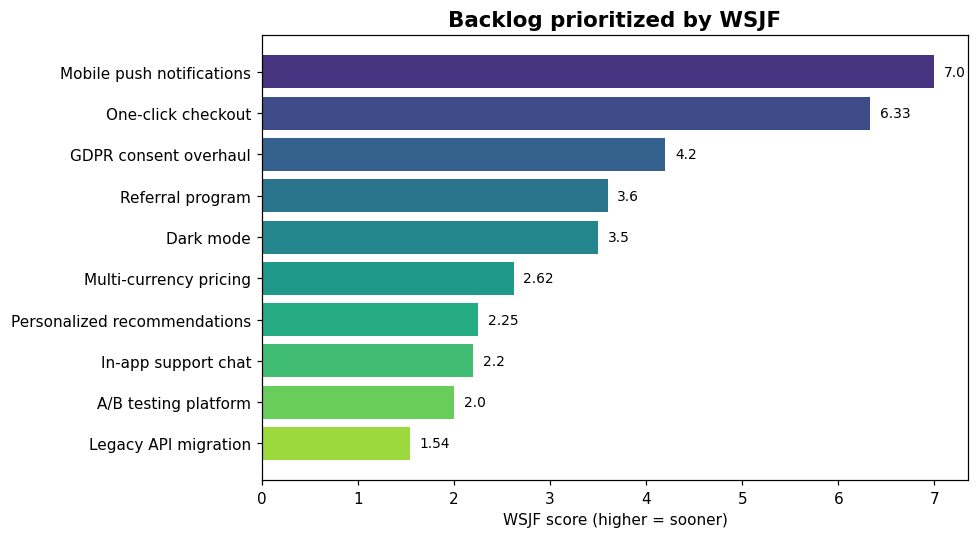

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(ranked_wsjf)))
bars = ax.barh(ranked_wsjf["initiative"], ranked_wsjf["wsjf"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("WSJF score (higher = sooner)")
ax.set_title("Backlog prioritized by WSJF", fontsize=14, fontweight="bold")
for bar, val in zip(bars, ranked_wsjf["wsjf"]):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, f"{val}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 5. WSJF rank vs. ROI rank — do they agree?

A quick sanity check every team should run: ranking by **WSJF** (value ÷ effort, time-boxed) and ranking by pure **ROI %** can disagree.

WSJF often promotes urgent or risk-reducing work (for example, compliance initiatives) that may have a weak standalone ROI but a high cost of delay.


In [ ]:
compare = backlog.copy()
compare["wsjf_rank"] = compare["wsjf"].rank(ascending=False).astype(int)
compare["roi_rank"] = compare["roi_pct"].rank(ascending=False).astype(int)
compare["rank_delta"] = compare["roi_rank"] - compare["wsjf_rank"]
compare = compare.sort_values("wsjf_rank")

display(compare[["initiative", "wsjf_rank", "roi_rank", "rank_delta"]]
        .set_index("initiative"))

,wsjf_rank,roi_rank,rank_delta
initiative,,,
Mobile push notifications,1,3,2
One-click checkout,2,1,-1
GDPR consent overhaul,3,9,6
Referral program,4,2,-2
Dark mode,5,5,0
Multi-currency pricing,6,6,0
Personalized recommendations,7,4,-3
In-app support chat,8,7,-1
A/B testing platform,9,8,-1


In [ ]:
biggest_mover = compare.loc[compare["rank_delta"].abs().idxmax()]

In [ ]:
biggest_mover

,7
initiative,GDPR consent overhaul
business_value,2
time_criticality,10
risk_reduction,9
job_size,5
cost_usd,70000
benefit_usd,80000
cost_of_delay,21
wsjf,4.2
roi_pct,14.0


In [ ]:
print(f"\nBiggest disagreement: '{biggest_mover['initiative']}' "
      f"\n(WSJF rank {int(biggest_mover['wsjf_rank'])} vs ROI rank {int(biggest_mover['roi_rank'])}) — "
      f"\nWSJF's time-criticality / risk-reduction terms are pulling this one forward "
      f"\neven though its dollar ROI alone wouldn't justify the priority.")


Biggest disagreement: 'GDPR consent overhaul' 
(WSJF rank 3 vs ROI rank 9) — 
WSJF's time-criticality / risk-reduction terms are pulling this one forward 
even though its dollar ROI alone wouldn't justify the priority.


## 6. Try it yourself — interactive re-scoring

Move the sliders to re-score **one** initiative live and watch it jump up or down the prioritized list.

This is exactly the conversation a prioritization workshop should produce:

> *"If we believe time-criticality is really a 9, not a 5, here's what changes."*

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

item_dropdown = widgets.Dropdown(
    options=list(backlog["initiative"]), description="Initiative:",
    style={"description_width": "initial"}, layout=widgets.Layout(width="350px"))
bv_slider = widgets.IntSlider(value=5, min=1, max=10, description="Business value")
tc_slider = widgets.IntSlider(value=5, min=1, max=10, description="Time criticality")
rr_slider = widgets.IntSlider(value=5, min=1, max=10, description="Risk reduction")
js_slider = widgets.IntSlider(value=5, min=1, max=13, description="Job size")
out = widgets.Output()

def sync_sliders(change=None):
    row = backlog[backlog["initiative"] == item_dropdown.value].iloc[0]
    bv_slider.value, tc_slider.value = int(row.business_value), int(row.time_criticality)
    rr_slider.value, js_slider.value = int(row.risk_reduction), int(row.job_size)

def redraw(change=None):
    temp = backlog.copy()
    mask = temp["initiative"] == item_dropdown.value
    temp.loc[mask, "business_value"] = bv_slider.value
    temp.loc[mask, "time_criticality"] = tc_slider.value
    temp.loc[mask, "risk_reduction"] = rr_slider.value
    temp.loc[mask, "job_size"] = js_slider.value
    temp["wsjf"] = ((temp.business_value + temp.time_criticality + temp.risk_reduction)
                     / temp.job_size).round(2)
    temp = temp.sort_values("wsjf", ascending=False).reset_index(drop=True)
    temp.index += 1
    with out:
        clear_output(wait=True)
        display(temp[["initiative", "wsjf"]].style.apply(
            lambda s: ['background-color: #cadcfc' if v == item_dropdown.value else ''
                       for v in temp["initiative"]], axis=0, subset=["initiative"]))

item_dropdown.observe(lambda c: (sync_sliders(), redraw()), names="value")
for s in (bv_slider, tc_slider, rr_slider, js_slider):
    s.observe(redraw, names="value")

sync_sliders(); redraw()
display(widgets.VBox([item_dropdown, bv_slider, tc_slider, rr_slider, js_slider, out]))